In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from tqdm import tqdm, tqdm_notebook
import random

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.initializers import *
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

#You can import other libraries if you want

In [4]:
###### DO NOT MODIFY THIS PART
seed = 2024
os.environ['PYTHONHASHSEED'] = str(seed) # fix your random seed : In same model, you produce the same result
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
from keras import backend as K
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)
######

2025-04-18 17:45:32.610318: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-04-18 17:45:32.610345: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-04-18 17:45:32.610351: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-04-18 17:45:32.610596: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-18 17:45:32.610630: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
artists = pd.read_csv(
    '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/artists_train.csv',
    usecols=lambda col: col not in ['bio', 'wikipedia'],  # 제외할 컬럼
    encoding='utf-8',
    engine='python'
)
# Sort artists by number of paintings
artists = artists.sort_values(by=['paintings'], ascending=False)

# Create a dataframe
artists_top = artists[artists['paintings'] >= 0].reset_index()
artists_top = artists_top[['name', 'paintings']]

updated_name = "Albrecht_Durer".replace("_", " ")
artists_top.iloc[4, 0] = updated_name

In [6]:
# Explore images of top artists
images_dir = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train'
artists_dirs = os.listdir(images_dir)
artists_top_name = sorted([
    d for d in os.listdir(images_dir)
    if os.path.isdir(os.path.join(images_dir, d))
])


# See if all directories exist
for name in artists_top_name:
    if os.path.exists(os.path.join(images_dir, name)):  # images_idr: directory folder // name: label (y)
        print("find -->", os.path.join(images_dir, name))
    else:
        print("Did not find -->", os.path.join(images_dir, name))

find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Albrecht_Durer
find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Alfred_Sisley
find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Edgar_Degas
find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Francisco_Goya
find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Marc_Chagall
find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Pablo_Picasso
find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Paul_Gauguin
find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Pierre-Auguste_Renoir
find --> /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train/Rembrandt
find --> /Users/kimdohyeon/건양대학교병원_

In [8]:
batch_size = 32
img_height = 244
img_width = 244
input_shape = (img_height, img_width)
n_classes = artists_top_name[0]
classes = artists_top_name

#Image data generate with validation data fraction of 0.2 and data rescale 1/255.
train_datagen = ImageDataGenerator(validation_split=0.2,
                                   rescale=1./255,
                                   horizontal_flip=True,
                                   vertical_flip=True
                                  )

train_generator = train_datagen.flow_from_directory(directory='/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/train',
                                                    class_mode='categorical',
                                                    target_size=input_shape,
                                                    batch_size=batch_size,
                                                    subset="training",
                                                    shuffle=True,
                                                    classes=classes
                                                   )

valid_generator = train_datagen.flow_from_directory(directory='/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/art/val',
                                                    class_mode='categorical',
                                                    target_size=input_shape,
                                                    batch_size=batch_size,
                                                    subset="validation",
                                                    shuffle=False,
                                                    classes=classes
                                                   )

STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = valid_generator.n//valid_generator.batch_size
print("Total number of batches =", STEP_SIZE_TRAIN, "and", STEP_SIZE_VALID)

Found 2470 images belonging to 11 classes.
Found 152 images belonging to 11 classes.
Total number of batches = 77 and 4


In [9]:
from scipy import ndimage

image, label = next(iter(train_generator))
image.shape, label.shape

((32, 244, 244, 3), (32, 11))

In [10]:
#######################
# Make your own model #
#######################
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.applications import VGG16

img_height = 244
img_width = 244
#num_classes = len(classes) # img_height, img_width
num_classes = len(artists_top_name)


# 1. VGG16 불러오기
base_model = VGG16(include_top=False,  # FC층 제외
                   weights='imagenet', # 사전학습 가중치 사용
                   input_shape=(img_height, img_width, 3))

# 2. VGG16의 레이어 동결 (feature extractor로만 사용)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

2025-04-18 17:45:44.403668: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-18 17:45:44.403690: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


#### 📍 VGG16 Model

모델 구조
Input (224x224x3)    
→ Conv3-64 → Conv3-64 → MaxPool   
→ Conv3-128 → Conv3-128 → MaxPool   
→ Conv3-256 → Conv3-256 → Conv3-256 → MaxPool   
→ Conv3-512 → Conv3-512 → Conv3-512 → MaxPool   
→ Conv3-512 → Conv3-512 → Conv3-512 → MaxPool   
→ FC-4096 → FC-4096 → FC-1000 → Softmax   

파라미터
1. include_top=False: FC layer 포함 여부 (False: 제외)
2. weights='imagenet': 'imagenet'(사전학습 가중치 사용) or None (랜덤 초기화)
3. input_tensor=None: input으로 사용할 텐서
4. input_shape=(244,244,3): 입력 이미지 shape (include_top=True면 (244,244,3)만 허용)
5. pooling=None: 'avg', 'max' 설정 시, Global Pooling 적용
6. classes=1000: FC layer의 출력 클래스 수 (include_top=True일 때만 사용)

[이미 학습된 모델] + [내 데이터용 출력층 추가]   
         ↓   
   Freeze → 학습   
         ↓   
   일부 Unfreeze → 파인튜닝 (사전학습 모델을 가져와서 내 데이터에 학습시키는 것)   
         ↓   
     더 나은 성능

#### 📍 EarlyStopping
-> 검증데이터의 성능이 일정 에폭 동안 향상되지 않으면 학습을 자동으로 중단시키는 콜백

파라미터
1. monitor='val_loss': 모니터링 할 지표 ('val_accuracy'도 가능)
2. patience=num: 몇 번까지 개선이 없는 걸 확인할건지
3. restore_best_weights=True: 가장 성이 좋았던 모델의 weight를 복원할 것인지
4. verbose=0/1/2: 로그출력
5. min_delta=num: 향상이라고 판단할 최소 변화량 (0.001이나 0.01 등등..)

#### 📍 Adam (Adaptive Moment Estimation)

- learning_rate: 가중치를 얼마나 빠르게 바꿀지 결정하는 숫자 (얼마나 크게 개선할거냐?)

**너무 크면?** : 한 번에 많이 움직여서 발산   
**너무 작으면?** : 너무 작게 움직여서 언제 끝날지 모름



In [13]:
# complie
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True)

model.compile(optimizer=legacy.Adam(learning_rate=1e-4),  # 
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
#training
n_epoch = 30
history = model.fit(train_generator, 
                   steps_per_epoch=STEP_SIZE_TRAIN,
                   validation_data=valid_generator, 
                   validation_steps=STEP_SIZE_VALID,
                   epochs=n_epoch,
                   callbacks=[early_stop])

Epoch 1/30


2025-04-18 17:46:03.495040: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


77/77 [==============================] - ETA: 0s - loss: 2.6655 - accuracy: 0.1395

2025-04-18 17:46:23.544189: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


77/77 [==============================] - 22s 251ms/step - loss: 2.6655 - accuracy: 0.1395 - val_loss: 2.3639 - val_accuracy: 0.1484
Epoch 2/30
77/77 [==============================] - 18s 237ms/step - loss: 2.4915 - accuracy: 0.1825 - val_loss: 2.3030 - val_accuracy: 0.1328
Epoch 3/30
77/77 [==============================] - 18s 237ms/step - loss: 2.3847 - accuracy: 0.1981 - val_loss: 2.2555 - val_accuracy: 0.1797
Epoch 4/30
77/77 [==============================] - 18s 237ms/step - loss: 2.3290 - accuracy: 0.2215 - val_loss: 2.1837 - val_accuracy: 0.2266
Epoch 5/30
77/77 [==============================] - 18s 237ms/step - loss: 2.2656 - accuracy: 0.2391 - val_loss: 2.1588 - val_accuracy: 0.2344
Epoch 6/30
77/77 [==============================] - 18s 238ms/step - loss: 2.1883 - accuracy: 0.2646 - val_loss: 2.1091 - val_accuracy: 0.2500
Epoch 7/30
77/77 [==============================] - 18s 236ms/step - loss: 2.1323 - accuracy: 0.2814 - val_loss: 2.0621 - val_accuracy: 0.2656
Epoch 8/30

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


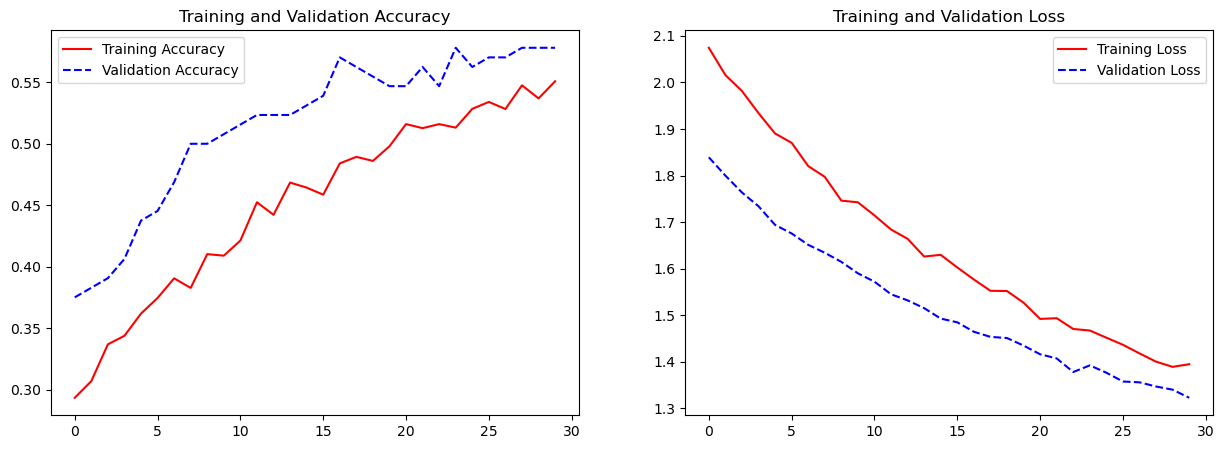

In [48]:
his = history.history.keys() #{}
print(his)
his = dict()

his['loss'] = history.history['loss']
his['accuracy'] = history.history['accuracy']
his['val_loss'] = history.history['val_loss']
his['val_accuracy'] = history.history['val_accuracy']

# Plot the training graph
def plot_training(history):
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(15,5))

    axes[0].plot(epochs, acc, 'r-', label='Training Accuracy')
    axes[0].plot(epochs, val_acc, 'b--', label='Validation Accuracy')
    axes[0].set_title('Training and Validation Accuracy')
    axes[0].legend(loc='best')

    axes[1].plot(epochs, loss, 'r-', label='Training Loss')
    axes[1].plot(epochs, val_loss, 'b--', label='Validation Loss')
    axes[1].set_title('Training and Validation Loss')
    axes[1].legend(loc='best')

    plt.show()

plot_training(his)

In [ ]:
model.save("/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/my_model_VGG16")

INFO:tensorflow:Assets written to: /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/my_model/assets


INFO:tensorflow:Assets written to: /Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/my_model/assets


# test

In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from tqdm import tqdm, tqdm_notebook
import random

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.initializers import *

#You can import other libraries if you want

In [34]:
###### DO NOT MODIFY THIS PART
seed = 2024
os.environ['PYTHONHASHSEED'] = str(seed)  # fix your random seed : In same model, you produce the same result
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
from keras import backend as K
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf) # tensorflow class for your operation
tf.compat.v1.keras.backend.set_session(sess)
######

2025-04-18 16:23:54.531719: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-18 16:23:54.531739: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [35]:
artists = pd.read_csv('/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/artists_test.csv') # type your directory, artists_test.csv
# Sort artists by number of paintings
artists = artists.sort_values(by=['paintings'], ascending=False)

# Create a dataframe
artists_top = artists[artists['paintings'] >= 0].reset_index()
artists_top = artists_top[['name', 'paintings']]

updated_name = "Albrecht_Durer".replace("_", " ")
artists_top.iloc[4, 0] = updated_name

In [36]:
### DO NOT EXCUTE THIS SHELL ###
#Test set load
test_images_dir = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/test/test/images'  # type your directory, test images folder
artists_dirs = os.listdir(test_images_dir)
print(len(artists_dirs))

artists_top_name = artists_top['name'].str.replace(' ', '_').values

input_shape = (img_height, img_width)
n_classes = artists_top.shape[0]
print(n_classes)
classes=artists_top_name.tolist() #

test_datagen = ImageDataGenerator()

test_generator = test_datagen.flow_from_directory(directory=test_images_dir,
                                                    class_mode='categorical',
                                                    target_size=input_shape,
                                                    batch_size=1,
                                                    shuffle=False,
                                                    seed=seed,
                                                    classes=artists_top_name.tolist()
                                                   )
print(test_generator.n)

1
11
Found 0 images belonging to 11 classes.
0


In [37]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_images_dir = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/test/test/images/images' # test images folder
img_height = 244
img_width = 244
test_image_files = os.listdir(test_images_dir)

test_filenames = sorted([f for f in os.listdir(test_images_dir) if f.endswith('.jpg')])

class_names = artists_top['name'].str.replace(" ", "_").tolist()


In [38]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

model = load_model('/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/DL/art_classification/my_model')

X_test = []
for fname in tqdm(test_filenames):
    img_path = os.path.join(test_images_dir, fname)
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img) / 255.0
    X_test.append(img_array)

X_test = np.array(X_test)

# 예측
preds = model.predict(X_test, batch_size=32)
pred_classes = np.argmax(preds, axis=1)

# index to label mapping (train_generator 쓴 경우 그걸로부터 class_indices 받아오는 게 best!)
idx_to_label = {i: label for i, label in enumerate(class_names)}
pred_labels = [idx_to_label[i] for i in pred_classes]

# 저장
submission = pd.DataFrame({
    "filename": test_filenames,
    "prediction": pred_labels
})
submission.to_csv("submission.csv", index=False)

100%|██████████| 220/220 [00:00<00:00, 297.26it/s]


1/7 [===>..........................] - ETA: 0s

2025-04-18 16:24:05.129718: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


7/7 [==============================] - 2s 256ms/step
